In [1]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if not os.path.exists('logger.py'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/td3_and_sac/logger.py

if IN_COLAB and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

!pip -q install "gymnasium[mujoco]" tensorboardX -i https://pypi.org/simple/
os.environ["MUJOCO_GL"] = "egl"

if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    if os.path.exists('../xvfb'):
        !bash ../xvfb start
        os.environ['DISPLAY'] = ':1'

Homework 3 SAC

# Continuous Control


In this notebook you will solve continuous control environment using [Soft Actor-Critic (SAC)](https://arxiv.org/pdf/1801.01290.pdf). It's an off-policy algorith that is still go-to algorithm for continuous control tasks.

SAC is an extension extensions of basic [Deep Deterministic Policy Gradient (DDPG)](https://arxiv.org/abs/1509.02971) algorithm, and DDPG is kind of "DQN with another neural net approximating greedy policy".

There is a set of stabilization tricks:
* SAC uses *stochastic policy*. This means that for SAC you can solve exploration-exploitation trade-off by simple sampling from policy.
* In SAC, we formally switch to formalism of Maximum Entropy RL and add *entropy bonus* into our value function.

More detailed description of algorithms can be found in Spinning Up documentation:

* on [SAC](https://spinningup.openai.com/en/latest/algorithms/sac.html)

## Environment

In [2]:
import gymnasium as gym
import numpy as np

First, we will create an instance of the environment.

In [3]:
env = gym.make("Ant-v5", render_mode="rgb_array", include_cfrc_ext_in_observation=False)

# we want to look inside
env.reset()

# examples of states and actions
print("observation space: ", env.observation_space,
      "\nobservations:", env.reset()[0])
print("action space: ", env.action_space,
      "\naction_sample: ", env.action_space.sample())

observation space:  Box(-inf, inf, (27,), float64) 
observations: [ 8.27991801e-01  9.16042267e-01 -8.50780771e-02  9.90555837e-02
 -3.44857439e-02  6.38545333e-02 -7.96997578e-02  1.69786486e-02
 -7.59501974e-02  8.29406025e-02 -3.60168440e-02  7.43456348e-03
 -2.91352737e-02  6.17348026e-02 -5.14090260e-02  2.02772431e-02
 -7.25749256e-02 -3.47544227e-04 -4.16314776e-02 -2.23083838e-01
 -1.55656368e-01  9.83122361e-03  2.78663558e-02  1.42716284e-01
 -4.30188327e-02  1.53079540e-01 -1.01369410e-01]
action space:  Box(-1.0, 1.0, (8,), float32) 
action_sample:  [ 0.17765306  0.9865811   0.5182676   0.6970423  -0.08910466 -0.36333543
  0.46661937 -0.5469078 ]


In [4]:
!pip install matplotlib

Looking in indexes: https://pypi.yandex-team.ru/simple/


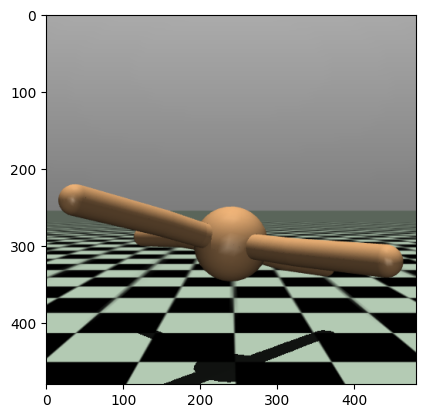

In [5]:
import matplotlib.pyplot as plt

plt.imshow(env.render())

Let's run random policy and see how it looks.

In [6]:
class RandomActor():
    def get_action(self, states):
        assert len(states.shape) == 1, "can't work with batches"
        return env.action_space.sample()

In [7]:
s, _ = env.reset()
rewards_per_step = []
actor = RandomActor()

for i in range(10000):
    a = actor.get_action(s)
    s, r, terminated, truncated, _ = env.step(a)

    rewards_per_step.append(r)

    if terminated or truncated:
        s, _ = env.reset()
        print("done: ", i)

done:  334
done:  373
done:  402
done:  419
done:  577
done:  739
done:  1018
done:  2018
done:  2377
done:  2417
done:  2448
done:  2492
done:  3492
done:  3511
done:  3618
done:  3650
done:  3678
done:  3790
done:  3817
done:  3831
done:  3955
done:  3975
done:  4024
done:  4215
done:  4605
done:  4744
done:  4789
done:  4917
done:  4968
done:  5968
done:  6036
done:  6116
done:  6330
done:  6342
done:  6453
done:  6489
done:  6538
done:  6631
done:  6718
done:  6898
done:  6914
done:  6993
done:  7282
done:  7397
done:  8397
done:  8562
done:  8625
done:  8878
done:  9113
done:  9222
done:  9304
done:  9363
done:  9519
done:  9723
done:  9758
done:  9818


So, basically most episodes are 1000 steps long (then happens termination by time), though sometimes we are terminated earlier if simulation discovers some obvious reasons to think that we crashed our ant. Important thing about continuous control tasks like this is that we receive non-trivial signal at each step:

In [8]:
rewards_per_step[100:110]

[np.float64(-1.1326297757266248),
 np.float64(-1.3745563813480581),
 np.float64(-0.6316339765510595),
 np.float64(-0.2781616147225143),
 np.float64(0.5860393356266302),
 np.float64(0.186905286038205),
 np.float64(0.2686616414330105),
 np.float64(-0.6138372483807506),
 np.float64(-0.14648626753807825),
 np.float64(0.45924650483874796)]

This dense signal will guide our optimizations. It also partially explains why off-policy algorithms are more effective and sample-efficient than on-policy algorithms like PPO: 1-step targets are already quite informative.

In [9]:
env.close()

We will add only one wrapper to our environment to simply write summaries, mainly, the total reward during an episode.

In [10]:
from logger import TensorboardSummaries as Summaries

env = gym.make("Ant-v5", render_mode="rgb_array", include_cfrc_ext_in_observation=False)
env = Summaries(env, "MyFirstAnt");

state_dim = env.observation_space.shape[0]  # dimension of state space (27 numbers)
action_dim = env.action_space.shape[0]      # dimension of action space (8 numbers)

## Task 1 (2 points out of 10)

## Models

Let's start with *critic* model. On the one hand, it will function as an approximation of $Q^*(s, a)$, on the other hand it evaluates current actor $\pi$ and can be viewed as $Q^{\pi}(s, a)$. This critic will take both state $s$ and action $a$ as input and output a scalar value. Recommended architecture is 3-layered MLP.

**Danger:** when models have a scalar output it is a good rule to squeeze it to avoid unexpected broadcasting, since [batch_size, 1] broadcasts with many tensor sizes.

In [11]:
!pip install torch

Looking in indexes: https://pypi.yandex-team.ru/simple/


In [12]:
import torch
import torch.nn as nn
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(state_dim + action_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 300),
            nn.ReLU(),
            nn.Linear(300, 1)
        )

    def get_qvalues(self, states, actions):
        '''
        input:
            states - tensor, (batch_size x features)
            actions - tensor, (batch_size x actions_dim)
        output:
            qvalues - tensor, critic estimation, (batch_size)
        '''
        qvalues = self.model(torch.cat([states, actions], dim=1)).squeeze(-1)

        assert len(qvalues.shape) == 1 and qvalues.shape[0] == states.shape[0]

        return qvalues

Next, let's define a policy, or an actor $\pi$. Use architecture, similar to critic (3-layered MLP).

For **SAC**, model *gaussian policy*. This means policy distribution is going to be multivariate normal with diagonal covariance. The policy head will predict the mean and covariance, and it should be guaranteed that covariance is non-negative. **Important:** the way you model covariance strongly influences optimization procedure, so here are some options: let $f_{\theta}$ be the output of covariance head, then:
* `softplus` operation $\sigma(s) = \log(1 + \exp({f_{\theta}(s)}))$.

**Note**: `torch.distributions.Normal` already has everything you will need to work with such policy after you modeled mean and covariance, i.e. sampling via reparametrization trick (see `rsample` method) and compute log probability (see `log_prob` method).

There is one more problem with gaussian distribution. We need to force our actions to be in $[-1, 1]$ bound. To achieve this, model unbounded gaussian $\mathcal{N}(\mu_{\theta}(s), \sigma_{\theta}(s)^2I)$, where $\mu$ can be arbitrary. Then every time you have samples $u$ from this gaussian policy, squash it using $\operatorname{tanh}$ function to get a sample from $[-1, 1]$:
$$u \sim \mathcal{N}(\mu, \sigma^2I)$$
$$a = \operatorname{tanh}(u)$$

**Important:** after that you are required to use change of variable formula every time you compute likelihood (see appendix C in [paper on SAC](https://arxiv.org/pdf/1801.01290.pdf) for details):
$$\log p(a \mid \mu, \sigma) = \log p(u \mid \mu, \sigma) - \sum_{i = 1}^D \log (1 - \operatorname{tanh}^2(u_i)),$$
where $D$ is `action_dim`. In practice, add something like 1e-6 inside logarithm to protect from computational instabilities.

In [13]:
# template for SAC
from torch.distributions import Normal

class Actor(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(state_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 300),
            nn.ReLU(),
            nn.Linear(300, 2 * action_dim)
        )

    def apply(self, states, evaluate=False):
        '''
        For given batch of states samples actions and also returns its log prob.
        input:
            states - PyTorch tensor, (batch_size x features)
        output:
            actions - PyTorch tensor, (batch_size x action_dim)
            log_prob - PyTorch tensor, (batch_size)
        '''
        mean, std = torch.chunk(self.model(states), 2, dim=-1)
        soft_plus_std = torch.nn.functional.softplus(std)
        dist = Normal(mean, soft_plus_std)
        if evaluate:
            actions = mean
            log_prob = None
            
        else:
            actions = dist.rsample()
            log_prob = torch.sum(dist.log_prob(actions), dim=-1) - torch.sum(torch.log(1 - torch.tanh(actions) ** 2 + 1e-6), dim=-1)
        actions = torch.tanh(actions)
        return actions, log_prob

        
    def get_action(self, states, evaluate=False):
        '''
        Used to interact with environment by sampling actions from policy
        input:
            states - numpy, (batch_size x features)
        output:
            actions - numpy, (batch_size x actions_dim)
        '''
        # no gradient computation is required here since we will use this only for interaction
        with torch.no_grad():

            # hint: you can use `apply` method here
            actions, _ = self.apply(torch.as_tensor(states, dtype=torch.float32, device=DEVICE), evaluate=evaluate)
            actions = actions.cpu().numpy()

            assert isinstance(actions, (list,np.ndarray)), "convert actions to numpy to send into env"
            assert actions.max() <= 1. and actions.min() >= -1, "actions must be in the range [-1, 1]"
            return actions

# Task 2 (3 points out of 10)

## ReplayBuffer

The same as in DQN. You can copy code from your DQN assignment, just check that it works fine with continuous actions (probably it is).

Let's recall the interface:
* `exp_replay.add(obs, act, rw, next_obs, done)` - saves (s,a,r,s',done) tuple into the buffer
* `exp_replay.sample(batch_size)` - returns observations, actions, rewards, next_observations and is_done for `batch_size` random samples.
* `len(exp_replay)` - returns number of elements stored in replay buffer.

In [14]:
class ReplayBuffer():
    def __init__(self, size, state_dim, action_dim):
        """
        Create Replay buffer.
        Parameters
        ----------
        size: int
            Max number of transitions to store in the buffer. When the buffer
            overflows the old memories are dropped.

        Note: for this assignment you can pick any data structure you want.
              If you want to keep it simple, you can store a list of tuples of (s, a, r, s') in self._storage
              However you may find out there are faster and/or more memory-efficient ways to do so.
        """
        self.size = size
        self.pos = 0
        self._storage = {
            "states": np.empty((size, state_dim)),
            "actions": np.empty((size, action_dim)),
            "rewards": np.empty((size,)),
            "next_states": np.empty((size, state_dim)),
            "dones": np.zeros((size,))
        }
        self.full = False

    def __len__(self):
        if self.full:
            return self.size
        else:
            return self.pos

    def add(self, obs_t, action, reward, obs_tp1, done):
        '''
        Make sure, _storage will not exceed _maxsize.
        Make sure, FIFO rule is being followed: the oldest examples has to be removed earlier
        '''
        self._storage["states"][self.pos] = obs_t
        self._storage["actions"][self.pos] = action
        self._storage["rewards"][self.pos] = reward
        self._storage["next_states"][self.pos] = obs_tp1
        self._storage["dones"][self.pos] = done
        
        self.pos = (self.pos + 1) % self.size
        if self.pos == 0:
            self.full = True



    def sample(self, batch_size):
        """Sample a batch of experiences.
        Parameters
        ----------
        batch_size: int
            How many transitions to sample.
        Returns
        -------
        obs_batch: np.array
            batch of observations
        act_batch: np.array
            batch of actions executed given obs_batch
        rew_batch: np.array
            rewards received as results of executing act_batch
        next_obs_batch: np.array
            next set of observations seen after executing act_batch
        done_mask: np.array
            done_mask[i] = 1 if executing act_batch[i] resulted in
            the end of an episode and 0 otherwise.
        """
        mask = np.random.choice(self.__len__(), batch_size)
        states = self._storage["states"][mask]
        actions = self._storage["actions"][mask]
        rewards = self._storage["rewards"][mask]
        next_states = self._storage["next_states"][mask]
        dones = self._storage["dones"][mask]

        return states, actions, rewards, next_states, dones
            # <states>, <actions>, <rewards>, <next_states>, <is_done>

In [15]:
action_dim, state_dim = env.action_space.shape[0], env.observation_space.shape[0]

In [16]:
exp_replay = ReplayBuffer(10, state_dim, action_dim)

for _ in range(30):
    exp_replay.add(env.reset()[0], env.action_space.sample(),
                   1.0, env.reset()[0], done=False)

obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = exp_replay.sample(
    5)

assert len(exp_replay) == 10, "experience replay size should be 10 because that's what maximum capacity is"

# Task 3 (1 point out of 10)

In [17]:
def play_and_record(initial_state, agent, env, exp_replay, n_steps=1):
    """
    Play the game for exactly n steps, record every (s,a,r,s', done) to replay buffer.
    Whenever game ends, add record with done=True and reset the game.
    It is guaranteed that env has done=False when passed to this function.

    :returns: return sum of rewards over time and the state in which the env stays
    """
    s = initial_state
    sum_rewards = 0

    # Play the game for n_steps as per instructions above
    for t in range(n_steps):

        # select action using policy with exploration
        a = agent.get_action(s)
        
        ns, r, terminated, truncated, _ = env.step(a)

        exp_replay.add(s, a, r, ns, terminated)

        s = env.reset()[0] if terminated or truncated else ns

        sum_rewards += r

    return sum_rewards, s

In [18]:
#testing your code.
exp_replay = ReplayBuffer(2000, state_dim, action_dim)
actor = Actor(state_dim, action_dim).to(DEVICE)

state, _ = env.reset()
play_and_record(state, actor, env, exp_replay, n_steps=1000)

# if you're using your own experience replay buffer, some of those tests may need correction.
# just make sure you know what your code does
assert len(exp_replay) == 1000, "play_and_record should have added exactly 1000 steps, "\
                                 "but instead added %i" % len(exp_replay)
is_dones = exp_replay._storage["dones"]

for _ in range(100):
    obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = exp_replay.sample(
        10)
    assert obs_batch.shape == next_obs_batch.shape == (10,) + (state_dim,)
    assert act_batch.shape == (
        10, action_dim), "actions batch should have shape (10, 8) but is instead %s" % str(act_batch.shape)
    assert reward_batch.shape == (
        10,), "rewards batch should have shape (10,) but is instead %s" % str(reward_batch.shape)
    assert is_done_batch.shape == (
        10,), "is_done batch should have shape (10,) but is instead %s" % str(is_done_batch.shape)
    assert [int(i) in (0, 1)
            for i in is_dones], "is_done should be strictly True or False"

print("Well done!")

Well done!


## Initialization

Let's start initializing our algorithm. Here is our hyperparameters:

In [19]:
gamma=0.99                    # discount factor
max_buffer_size = 10**5       # size of experience replay
start_timesteps = 5000        # size of experience replay when start training
timesteps_per_epoch=1         # steps in environment per step of network updates
batch_size=128                # batch size for all optimizations
max_grad_norm=10              # max grad norm for all optimizations
tau=0.005                     # speed of updating target networks
policy_update_freq=1          # frequency of actor update; vanilla choice is 1 for SAC
alpha=0.1                     # temperature for SAC

# iterations passed
n_iterations = 0

Here is our experience replay:

In [20]:
# experience replay
exp_replay = ReplayBuffer(max_buffer_size, state_dim, action_dim)

Here is our models: *two* critics and one actor.

In [21]:
# models to train
actor = Actor(state_dim, action_dim).to(DEVICE)
critic1 = Critic(state_dim, action_dim).to(DEVICE)
critic2 = Critic(state_dim, action_dim).to(DEVICE)

To stabilize training, we will require **target networks** - slow updating copies of our models. In **SAC** it is assumed that only critics require target copies while actor is always used fresh.

In [22]:
# target networks: slow-updated copies of actor and two critics
target_critic1 = Critic(state_dim, action_dim).to(DEVICE)
target_critic2 = Critic(state_dim, action_dim).to(DEVICE)

# initialize them as copies of original models
target_critic1.load_state_dict(critic1.state_dict())
target_critic2.load_state_dict(critic2.state_dict())

<All keys matched successfully>

In continuous control, target networks are usually updated using exponential smoothing:
$$\theta^{-} \leftarrow \tau \theta + (1 - \tau) \theta^{-},$$
where $\theta^{-}$ are target network weights, $\theta$ - fresh parameters, $\tau$ - hyperparameter. This util function will do it:

In [23]:
def update_target_networks(model, target_model):
    for param, target_param in zip(model.parameters(), target_model.parameters()):
          target_param.data.copy_(tau * param.data + (1 - tau) * target_param.data)

Finally, we will have three optimization procedures to train our three models, so let's welcome our three Adams:

In [24]:
# optimizers: for every model we have
opt_actor = torch.optim.Adam(actor.parameters(), lr=3e-4)
opt_critic1 = torch.optim.Adam(critic1.parameters(), lr=3e-4)
opt_critic2 = torch.optim.Adam(critic2.parameters(), lr=3e-4)

In [25]:
# just to avoid writing this code three times
def optimize(name, model, optimizer, loss):
    '''
    Makes one step of SGD optimization, clips norm with max_grad_norm and
    logs everything into tensorboard
    '''
    loss = loss.mean()
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    grad_norm = nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
    optimizer.step()

    # logging
    env.writer.add_scalar(name, loss.item(), n_iterations)
    env.writer.add_scalar(name + "_grad_norm", grad_norm.item(), n_iterations)

## Task 4 (2 points out of 10)

## Critic target computation

Finally, let's discuss our losses for critic and actor.

To train both critics we would like to minimize MSE using 1-step targets: for one sampled transition $(s, a, r, s')$ it should look something like this:
$$y(s, a) = r + \gamma V(s').$$

How do we evaluate next state and compute $V(s')$? Well, technically Monte-Carlo estimation looks simple:
$$V(s') \approx Q(s', a')$$
where (important!) $a'$ is a sample from our current policy $\pi(a' \mid s')$.

But out actor $\pi$ will be actually trained to search for actions $a'$ where our critic gives big estimates, and this straightforward approach leads to serious overesimation issues. We require some hacks. First, we will use target networks for $Q$. Second, we will use *two* critics and take minimum across their estimations:
$$V(s') = \min_{i = 1,2} Q^{-}_i(s', a'),$$
where $a'$ is sampled from fresh policy $\pi(a' \mid s')$.

###### And the last but not the least:
* in **SAC** add (estimation of) entropy bonus in next state $s'$:
$$V(s') = \min_{i = 1,2} Q^{-}_i(s', a') - \alpha \log \pi (a' \mid s')$$

In [26]:
def compute_critic_target(rewards, next_states, is_done, alpha):
    '''
    Important: use target networks for this method! Do not use "fresh" models except fresh policy in SAC!
    input:
        rewards - PyTorch tensor, (batch_size)
        next_states - PyTorch tensor, (batch_size x features)
        is_done - PyTorch tensor, (batch_size)
    output:
        critic target - PyTorch tensor, (batch_size)
    '''
    with torch.no_grad():
        actions, log_prob = actor.apply(next_states)
        critic_target = rewards + gamma * (1 - is_done) * (torch.min(
            target_critic1.get_qvalues(next_states, actions),
            target_critic2.get_qvalues(next_states, actions)
        ) - alpha * log_prob)

    assert not critic_target.requires_grad, "target must not require grad."
    assert len(critic_target.shape) == 1, "dangerous extra dimension in target?"

    return critic_target


In **SAC**, use reparametrization trick to compute gradients and also do not forget to add entropy regularizer to motivate policy to be as stochastic as possible:
$$\mathbb{E}_{a \sim \pi(a \mid s)} Q(s, a) - \alpha \log \pi(a \mid s) \to \max_{\pi}$$

**Note:** We will use (fresh) critic1 here as Q-functon to "exploit". You can also use both critics and again take minimum across their estimations (this is done in original implementation of **SAC**), but this seems to be not of high importance.

In [27]:
def compute_actor_loss(states, alpha):
    '''
    Returns actor loss on batch of states
    input:
        states - PyTorch tensor, (batch_size x features)
    output:
        actor loss - PyTorch tensor, (batch_size)
    '''
    # make sure you have gradients w.r.t. actor parameters
    actions, log_prob = actor.apply(states)
    assert actions.requires_grad, "actions must be differentiable with respect to policy parameters"

    # compute actor loss
    actor_loss = (alpha * log_prob - critic1.get_qvalues(states, actions))
    return actor_loss

In [28]:
def compute_critic_loss(qvalues, rewards, next_states, is_done, alpha):
    critic_target = compute_critic_target(rewards, next_states, is_done, alpha)
    critic_loss = (critic_target - qvalues).pow(2).mean()
    return critic_loss

## Task 5 (2 points out of 10)

# Pipeline

Finally combining all together and launching our algorithm. Your goal is to reach at least 1000 average reward during evaluation after training in this ant environment (*since this is a new hometask, this threshold might be updated, so at least just see if your ant learned to walk in the rendered simulation*).

* rewards should rise more or less steadily in this environment. There can be some drops due to instabilities of algorithm, but it should eventually start rising after 100K-200K iterations. If no progress in reward is observed after these first 100K-200K iterations, there is a bug.
* gradient norm appears to be quite big for this task, it is ok if it reaches 100-200 (we handled it with clip_grad_norm). Consider everything exploded if it starts growing exponentially, then there is a bug.

In [29]:
!pip install tensorboard


Looking in indexes: https://pypi.yandex-team.ru/simple/


In [30]:
%load_ext tensorboard
%tensorboard --logdir logs


In [31]:
seed = 228
np.random.seed(seed)
torch.manual_seed(seed);

In [32]:
!pip install tqdm

Looking in indexes: https://pypi.yandex-team.ru/simple/


In [33]:
from tqdm.notebook import trange

interaction_state, _ = env.reset()
random_actor = RandomActor()

for n_iterations in trange(0, 1000000, timesteps_per_epoch):
    # if experience replay is small yet, no training happens
    # we also collect data using random policy to collect more diverse starting data
    if len(exp_replay) < start_timesteps:
        _, interaction_state = play_and_record(interaction_state, random_actor, env, exp_replay, timesteps_per_epoch)
        continue

    # perform a step in environment and store it in experience replay
    _, interaction_state = play_and_record(interaction_state, actor, env, exp_replay, timesteps_per_epoch)

    # sample a batch from experience replay
    states, actions, rewards, next_states, is_done = exp_replay.sample(batch_size)

    # move everything to PyTorch tensors
    states = torch.tensor(states, device=DEVICE, dtype=torch.float)
    actions = torch.tensor(actions, device=DEVICE, dtype=torch.float)
    rewards = torch.tensor(rewards, device=DEVICE, dtype=torch.float)
    next_states = torch.tensor(next_states, device=DEVICE, dtype=torch.float)
    is_done = torch.tensor(
        is_done.astype('float32'),
        device=DEVICE,
        dtype=torch.float
    )

    # losses
    critic1_loss = compute_critic_loss(critic1.get_qvalues(states, actions), rewards, next_states, is_done, alpha)
    optimize("critic1", critic1, opt_critic1, critic1_loss)

    critic2_loss = compute_critic_loss(critic2.get_qvalues(states, actions), rewards, next_states, is_done, alpha)
    optimize("critic2", critic2, opt_critic2, critic2_loss)

    if n_iterations % policy_update_freq == 0:
        actor_loss = compute_actor_loss(states, alpha)
        optimize("actor", actor, opt_actor, actor_loss)

        # update target networks
        update_target_networks(critic1, target_critic1)
        update_target_networks(critic2, target_critic2)

  0%|          | 0/1000000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [39]:
import torch

ckpt = {
    "actor": actor.state_dict(),
    "critic1": critic1.state_dict(),
    "critic2": critic2.state_dict(),
    "target_critic1": target_critic1.state_dict(),
    "target_critic2": target_critic2.state_dict(),
    "opt_actor": opt_actor.state_dict(),
    "opt_critic1": opt_critic1.state_dict(),
    "opt_critic2": opt_critic2.state_dict(),
    "n_iterations": n_iterations,
}
torch.save(ckpt, "sac_checkpoint.pt")

## Evaluation

In [34]:
def evaluate(env, actor, n_games=1, t_max=1000):
    '''
    Plays n_games and returns rewards and rendered games
    '''
    rewards = []

    for _ in range(n_games):
        s, _ = env.reset()

        R = 0
        for _ in range(t_max):
            # select action for final evaluation of your policy
            action = actor.get_action(s, evaluate=True)

            assert (action.max() <= 1).all() and  (action.min() >= -1).all()

            s, r, terminated, truncated, _ = env.step(action)

            R += r

            if terminated or truncated:
                break

        rewards.append(R)
    return np.array(rewards)

In [35]:
# evaluation will take some time!
sessions = evaluate(env, actor, n_games=20)
score = sessions.mean()
print(f"Your score: {score}")

assert score >= 1000, "Needs more training?"
print("Well done!")

Your score: 4881.68131934664
Well done!


In [36]:
env.close()

## Record

In [ ]:
!pip install moviepy

In [40]:
from gymnasium.wrappers import RecordVideo

# let's hope this will work
# don't forget to pray
with gym.make("Ant-v5", render_mode="rgb_array", include_cfrc_ext_in_observation=False) as env, RecordVideo(
    env=env, video_folder="./videos"
) as env_monitor:
    # note that t_max is 300, so collected reward will be smaller than 1000
    evaluate(env_monitor, actor, n_games=1, t_max=300)

In [41]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML
import sys

video_paths = sorted([s for s in Path('videos').iterdir() if s.suffix == '.mp4'])
video_path = video_paths[-1]  # You can also try other indices

if 'google.colab' in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open('rb') as fp:
        mp4 = fp.read()
    data_url = 'data:video/mp4;base64,' + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML("""
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(data_url))

### Report

We'd like to collect some statistics about computational resources you spent on this task. Please, report:
* which GPU or CPU you used: NVIDIA H200 (143 GB), host CPU Intel Xeon Platinum 8558
* number of iterations you used for training: 1 000 000 * 0.7 \[early stopnul]
* wall-clock time spent (on computation =D): 2h30m